In [ ]:
!pip install -q kagglehub ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import torch
import clip
import os
import kagglehub
from PIL import Image
import matplotlib.pyplot as plt


In [ ]:
import os
os.environ['KAGGLE_USERNAME'] = "arunimabishen"
os.environ['KAGGLE_KEY'] = "KGAT_2314da96d771a207ed98c50bd104ffaf"

import kagglehub

# Download latest version
path = kagglehub.dataset_download("thusharanair/deepfashion2-original-with-dataframes")

print("Path to dataset files:", path)

100%|██████████| 14.9G/14.9G [06:20<00:00, 42.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/thusharanair/deepfashion2-original-with-dataframes/versions/2


In [ ]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    break


/root/.cache/kagglehub/datasets/thusharanair/deepfashion2-original-with-dataframes/versions/2


In [ ]:
os.listdir(path)


['DeepFashion2']

In [ ]:
import os

for root, dirs, files in os.walk(os.path.join(path, "DeepFashion2")):
    print(root)


/root/.cache/kagglehub/datasets/thusharanair/deepfashion2-original-with-dataframes/versions/2/DeepFashion2
/root/.cache/kagglehub/datasets/thusharanair/deepfashion2-original-with-dataframes/versions/2/DeepFashion2/img_info_dataframes
/root/.cache/kagglehub/datasets/thusharanair/deepfashion2-original-with-dataframes/versions/2/DeepFashion2/deepfashion2_original_images
/root/.cache/kagglehub/datasets/thusharanair/deepfashion2-original-with-dataframes/versions/2/DeepFashion2/deepfashion2_original_images/train
/root/.cache/kagglehub/datasets/thusharanair/deepfashion2-original-with-dataframes/versions/2/DeepFashion2/deepfashion2_original_images/train/annos
/root/.cache/kagglehub/datasets/thusharanair/deepfashion2-original-with-dataframes/versions/2/DeepFashion2/deepfashion2_original_images/train/image
/root/.cache/kagglehub/datasets/thusharanair/deepfashion2-original-with-dataframes/versions/2/DeepFashion2/deepfashion2_original_images/validation
/root/.cache/kagglehub/datasets/thusharanair/

In [ ]:
train_image_dir = os.path.join(path,
    "DeepFashion2/deepfashion2_original_images/train/image")

val_image_dir = os.path.join(path,
    "DeepFashion2/deepfashion2_original_images/validation/image")

test_image_dir = os.path.join(path,
    "DeepFashion2/deepfashion2_original_images/test/test/image")


In [ ]:
sample_img = os.path.join(train_image_dir, os.listdir(train_image_dir)[0])
sample_img

'/root/.cache/kagglehub/datasets/thusharanair/deepfashion2-original-with-dataframes/versions/2/DeepFashion2/deepfashion2_original_images/train/image/166858.jpg'

In [ ]:
import torch
import clip
from PIL import Image
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

print("Using device:", device)


100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 85.5MiB/s]


Using device: cuda


In [ ]:
classes = [
    "a photo of a top clothing",
    "a photo of trousers or pants",
    "a photo of a skirt",
    "a photo of a dress",
    "a photo of shorts"
]

# tokenize the classes
text_tokens = clip.tokenize(classes).to(device)

# encode once for efficiency
with torch.no_grad():
    text_features = model.encode_text(text_tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)


In [ ]:
def classify_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image_input = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        image_features = model.encode_image(image_input)
        image_features /= image_features.norm(dim=-1, keepdim=True)

        similarity = (100.0 * image_features @ text_features.T)
        probs = similarity.softmax(dim=-1)

    return probs.cpu().numpy()[0]


In [ ]:
def predict_label(image_path):
    probs = classify_image(image_path)
    idx = probs.argmax()
    return classes[idx], probs[idx], probs


In [ ]:
# Pick first image from training set
sample_img = os.path.join(train_image_dir, os.listdir(train_image_dir)[0])

label, confidence, probs = predict_label(sample_img)

print("Prediction:", label)
print("Confidence:", confidence)

for cls, p in zip(classes, probs):
    print(f"{cls}: {p:.4f}")


Prediction: a photo of a top clothing
Confidence: 0.7715
a photo of a top clothing: 0.7715
a photo of trousers or pants: 0.0037
a photo of a skirt: 0.0344
a photo of a dress: 0.0384
a photo of shorts: 0.1520


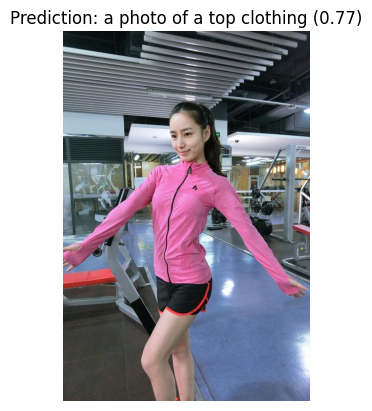

a photo of a top clothing: 0.7715
a photo of trousers or pants: 0.0037
a photo of a skirt: 0.0344
a photo of a dress: 0.0384
a photo of shorts: 0.1520


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Open the image
img = Image.open(sample_img)

# Display the image
plt.imshow(img)
plt.axis("off")  # remove axes
plt.title(f"Prediction: {label} ({confidence:.2f})")
plt.show()

# Optional: print class probabilities
for cls, p in zip(classes, probs):
    print(f"{cls}: {p:.4f}")


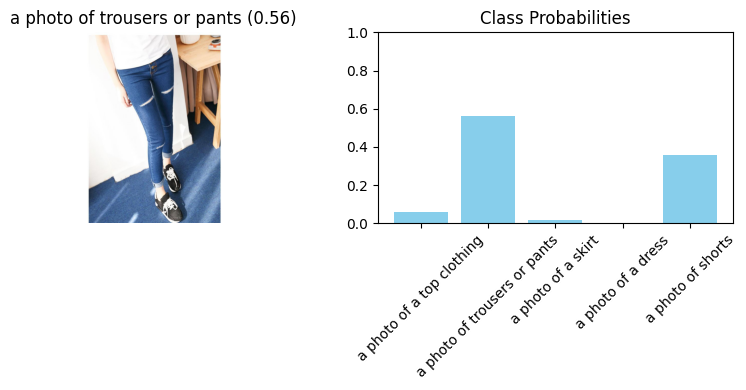

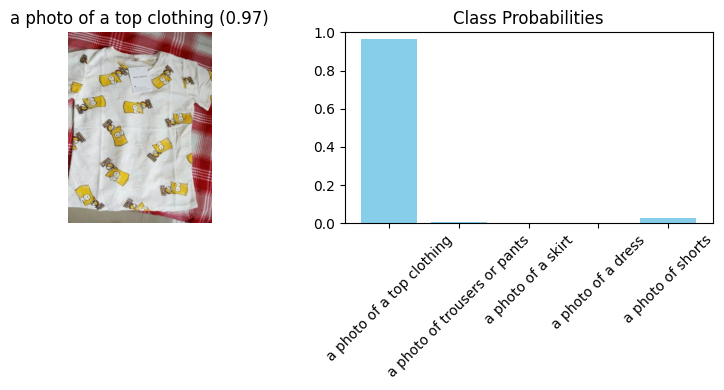

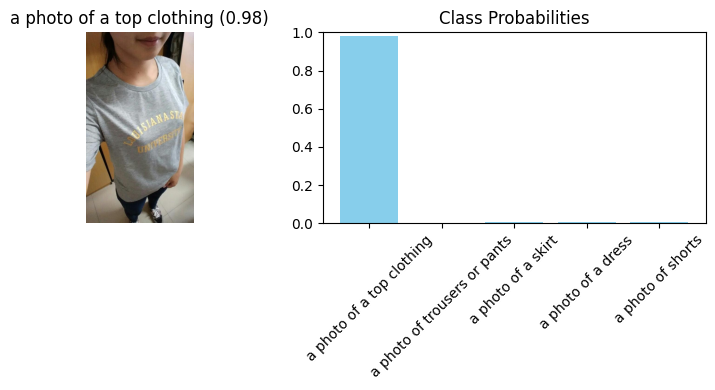

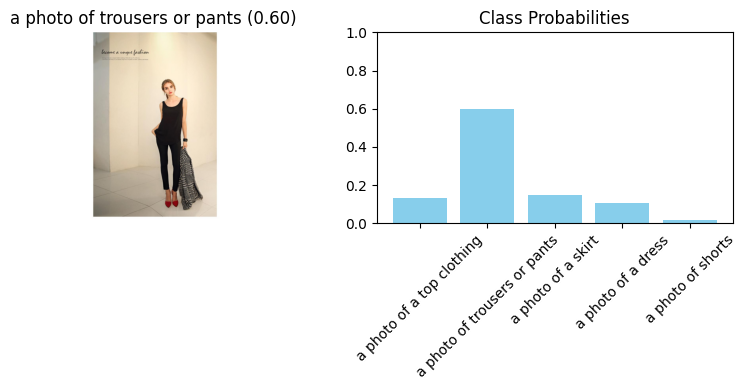

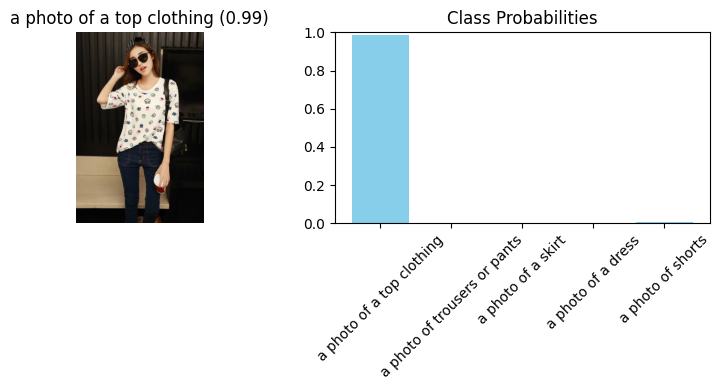

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Get list of all images in training set
all_train_images = os.listdir(train_image_dir)

# Pick 5 random images
sample_images = random.sample(all_train_images, 5)

for img_name in sample_images:
    img_path = os.path.join(train_image_dir, img_name)

    # Predict
    label, confidence, probs = predict_label(img_path)

    # Open image
    img = Image.open(img_path)

    # Plot image and prediction
    plt.figure(figsize=(8,4))

    # Subplot 1: the image
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{label} ({confidence:.2f})")

    # Subplot 2: bar chart of probabilities
    plt.subplot(1,2,2)
    plt.bar(classes, probs, color='skyblue')
    plt.ylim(0,1)
    plt.title("Class Probabilities")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


In [ ]:
from google.colab import files
uploaded = files.upload()  # select your jpg/png clothing image


Saving jeans.jpeg to jeans.jpeg


a photo of a top clothing: 0.0636
a photo of trousers or pants: 0.7871
a photo of a skirt: 0.0035
a photo of a dress: 0.0002
a photo of shorts: 0.1456


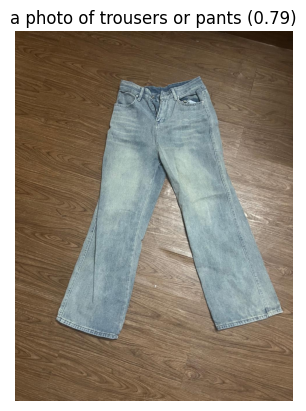

In [ ]:
user_image = list(uploaded.keys())[0]

label, confidence, probs = predict_label(user_image)

img = Image.open(user_image)
plt.imshow(img)
plt.axis("off")
plt.title(f"{label} ({confidence:.2f})")

for cls, p in zip(classes, probs):
    print(f"{cls}: {p:.4f}")


In [ ]:
from google.colab import files
uploaded = files.upload()  # select your jpg/png clothing image


Saving 2.jpeg to 2.jpeg


a photo of a top clothing: 0.9863
a photo of trousers or pants: 0.0002
a photo of a skirt: 0.0011
a photo of a dress: 0.0001
a photo of shorts: 0.0122


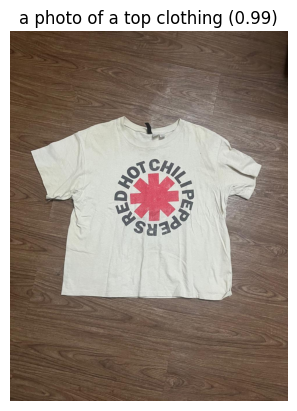

In [ ]:
user_image = list(uploaded.keys())[0]

label, confidence, probs = predict_label(user_image)

img = Image.open(user_image)
plt.imshow(img)
plt.axis("off")
plt.title(f"{label} ({confidence:.2f})")

for cls, p in zip(classes, probs):
    print(f"{cls}: {p:.4f}")


In [ ]:
# Style filters
style_filters = [
    "street fashion casual outfit",
    "party wear stylish outfit",
    "formal office outfit"
]

# Encode filters once
style_tokens = clip.tokenize(style_filters).to(device)
with torch.no_grad():
    style_features = model.encode_text(style_tokens)
    style_features /= style_features.norm(dim=-1, keepdim=True)


In [ ]:
from google.colab import files
uploaded = files.upload()  # select multiple clothing images


Saving pants.png to pants.png
Saving blazer.png to blazer.png
Saving dress.png to dress.png
Saving hoodie.png to hoodie.png
Saving tshirt.png to tshirt.png
Saving jeans.png to jeans.png


In [ ]:
uploaded_images = list(uploaded.keys())
print("Uploaded images:", uploaded_images)


Uploaded images: ['pants.png', 'blazer.png', 'dress.png', 'hoodie.png', 'tshirt.png', 'jeans.png']


In [ ]:
def classify_type(image_path):
    """Returns clothing type (top, dress, pants...)"""
    label, confidence, _ = predict_label(image_path)
    return label, confidence

def classify_style(image_path):
    """Returns style filter (Street, Party, Formal)"""
    image = Image.open(image_path).convert("RGB")
    image_input = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        image_features = model.encode_image(image_input)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        similarity = (100.0 * image_features @ style_features.T)
        probs = similarity.softmax(dim=-1)

    idx = probs.argmax()
    return style_filters[idx], probs[0, idx].item(), probs.cpu().numpy()[0]


In [ ]:
wardrobe = []  # store uploaded images with type + style

for img_name in uploaded_images:
    img_path = img_name
    clothing_type, type_conf = classify_type(img_path)
    style, style_conf, style_probs = classify_style(img_path)

    wardrobe.append({
        "image_path": img_path,
        "type": clothing_type,
        "type_conf": type_conf,
        "style": style,
        "style_conf": style_conf,
        "style_probs": style_probs
    })

    print(f"{img_name} -> Type: {clothing_type} ({type_conf:.2f}), Style: {style} ({style_conf:.2f})")


pants.png -> Type: a photo of trousers or pants (0.98), Style: formal office outfit (0.85)
blazer.png -> Type: a photo of a top clothing (0.89), Style: formal office outfit (0.80)
dress.png -> Type: a photo of a dress (0.82), Style: party wear stylish outfit (0.89)
hoodie.png -> Type: a photo of a top clothing (0.98), Style: formal office outfit (0.56)
tshirt.png -> Type: a photo of a top clothing (1.00), Style: party wear stylish outfit (0.63)
jeans.png -> Type: a photo of trousers or pants (0.73), Style: street fashion casual outfit (0.93)


In [ ]:
from itertools import combinations, product

def suggest_outfits(wardrobe, selected_style):
    # Filter items by style
    style_items = [item for item in wardrobe if item['style'] == selected_style]

    # Separate by type
    tops = [i for i in style_items if i['type'] in ['top', 'shirt', 'tshirt']]
    bottoms = [i for i in style_items if i['type'] in ['pants', 'trousers', 'jeans', 'joggers']]
    dresses = [i for i in style_items if i['type'] in ['dress', 'skirt']]

    suggestions = []

    # Dresses alone
    for d in dresses:
        suggestions.append([d['image_path']])

    # Top + Bottom combinations
    for t, b in product(tops, bottoms):
        suggestions.append([t['image_path'], b['image_path']])

    return suggestions


In [ ]:
selected_filter = "street fashion casual outfit"  # or Party / Formal
outfits = suggest_outfits(wardrobe, selected_filter)

print(f"Suggested outfits for {selected_filter}: {len(outfits)}")
for idx, outfit in enumerate(outfits[:5]):  # show first 5 suggestions
    print(f"Outfit {idx+1}: {outfit}")


Suggested outfits for street fashion casual outfit: 0


In [ ]:
def show_outfit(outfit):
    plt.figure(figsize=(8,4))
    for idx, img_path in enumerate(outfit):
        img = Image.open(img_path)
        plt.subplot(1, len(outfit), idx+1)
        plt.imshow(img)
        plt.axis("off")
    plt.show()

# Example: show first suggested outfit
show_outfit(outfits[0])


IndexError: list index out of range

In [ ]:
predicted_style, style_conf, _ = classify_style(img_path)

# fallback
if style_conf < 0.1:
    predicted_style = "street fashion casual outfit"


In [ ]:
for item in wardrobe:
    print(item['image_path'], "->", item['type'], item['style'], item['style_conf'])


pants.png -> a photo of trousers or pants formal office outfit 0.8486328125
blazer.png -> a photo of a top clothing formal office outfit 0.8017578125
dress.png -> a photo of a dress party wear stylish outfit 0.89013671875
hoodie.png -> a photo of a top clothing formal office outfit 0.55712890625
tshirt.png -> a photo of a top clothing party wear stylish outfit 0.63427734375
jeans.png -> a photo of trousers or pants street fashion casual outfit 0.93212890625


In [ ]:
from itertools import product

# --------------- STREET STYLE FINAL GENERATOR -----------------
def generate_street_outfits(wardrobe):
    """
    Returns all top+bottom combinations for street style,
    only hoodie, tshirt, jeans
    """
    street_names = ['hoodie','tshirt','jeans']

    # Pick only hoodie, tshirt, jeans
    street_items = [item for item in wardrobe
                    if any(name.lower() in item['image_path'].lower() for name in street_names)]

    # Separate tops and bottoms
    tops = [i for i in street_items if 'top' in i['type'].lower() or 'shirt' in i['type'].lower()]
    bottoms = [i for i in street_items if 'pant' in i['type'].lower() or 'jeans' in i['type'].lower() or 'jogger' in i['type'].lower()]

    # Generate top+bottom combos
    street_outfits = [[t['image_path'], b['image_path']] for t, b in product(tops, bottoms)]

    return street_outfits

In [ ]:
# Call once to get outfits
street_outfits = generate_street_outfits(wardrobe)

In [ ]:
print("Street style outfit combinations (filenames only):")
for idx, outfit in enumerate(street_outfits):
    print(f"Outfit {idx+1}: {outfit}")


Street style outfit combinations (filenames only):
Outfit 1: ['hoodie (1).png', 'jeans (1).png']
Outfit 2: ['tshirt (1).png', 'jeans (1).png']


Number of street outfits suggested: 2


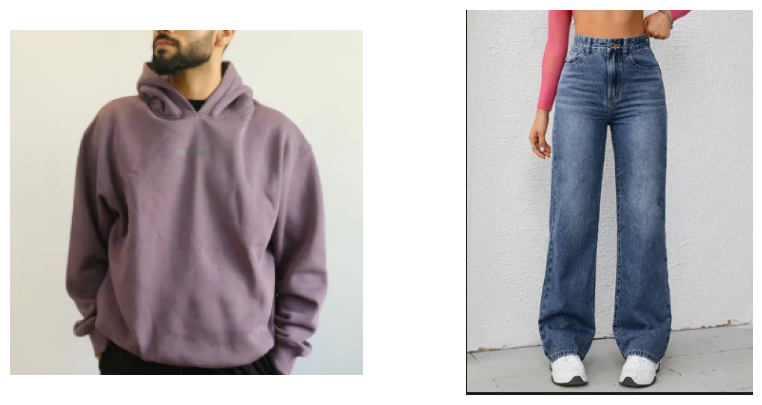

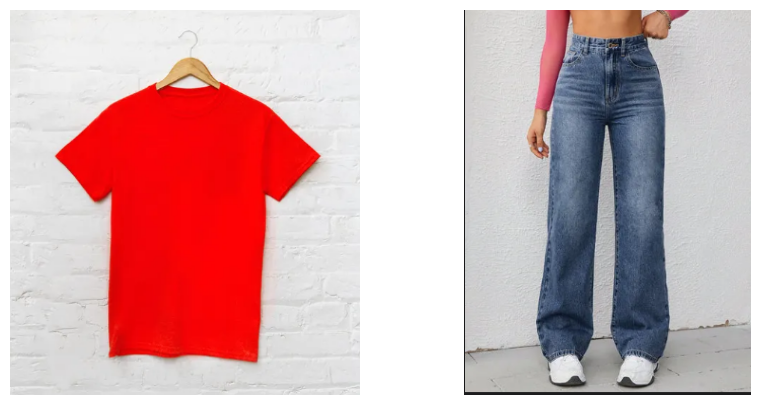

In [ ]:
treet_outfits = generate_street_outfits(wardrobe)

print(f"Number of street outfits suggested: {len(street_outfits)}")

# Show all outfits visually
for outfit in street_outfits:
    show_outfit(outfit)